# 4.3.2 Re-entrant sector (Appendix A.3.2)

Reproduces Figure 4.15 ($h$- and $p$-convergence on $\Omega_s(15^\circ)$ under $\beta_1$, `pacman_h_b1_BN2_d15.eps`, `pacman_p_b1_BN2_d15.eps`), Figure A.11 (the unstructured sector meshes) and Tables A.13-A.15 (reference spectra for $\beta_1$, $\beta_2$, $\beta_4$ at $\delta \in \{90^\circ, 45^\circ, 15^\circ, 5^\circ\}$). Imports the shared modules `spectral_common.py`, `pseudospectra_partial_schur.py` and `domain_meshes.py` from this folder. Run top to bottom in a kernel with Firedrake + SLEPc + MUMPS (Gmsh is needed by `domain_meshes`); figures are written to `./figures`.


## Setup


Matplotlib/LaTeX figure style, imports, `FIGDIR`, `show`, and the plotting helpers `save_fig`, `mesh_panel`, `floor_ref`, `conv_panel`.


In [1]:
import matplotlib.pyplot as plt

# 1. Document parameters
latex_textwidth_pt = 426.79135 # REPLACE with the number you got from \the\textwidth
inches_per_pt = 1.0 / 72.27
fig_width = latex_textwidth_pt * inches_per_pt
fig_height = fig_width * 0.75 # Standard 4:3 aspect ratio, adjust as needed

base_fontsize = 11 # Or 12, depending on your document class declaration

# 2. Update rcParams globally
plt.rcParams.update({
    "figure.figsize": (fig_width, fig_height),

    # Match LaTeX fonts
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Match font sizes exactly
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize,
    "axes.labelsize": base_fontsize,
    "legend.fontsize": base_fontsize - 1, # Slightly smaller for legend
    "xtick.labelsize": base_fontsize - 2, # Smaller for tick marks
    "ytick.labelsize": base_fontsize - 2,

    # Refine line weights for a professional look
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
})

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Optional
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib
from IPython.display import display, Markdown

from firedrake import *
from firedrake.pyplot import triplot

from petsc4py import PETSc

import spectral_common as sc
import pseudospectra_partial_schur as ps
from spectral_common import (solve_pencil, border_gauge, assign,
                             condition_estimates)
import domain_meshes as dm
from domain_meshes import (sector_hierarchy, graded_sector_mesh,
                           sector_maxwell_eigs, corner_rates)

# `from firedrake import *` exports a `logging` of its own.
import logging as stdlogging
stdlogging.getLogger("firedrake").setLevel(stdlogging.ERROR)
stdlogging.getLogger("tsfc").setLevel(stdlogging.ERROR)

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

# Everything the LaTeX block above does not set: fonts and sizes come from there.
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "savefig.pad_inches": 0.02})
FIG_SQ = (3.6, 3.4)       # one mesh or eigenfunction panel

#: The pseudospectrum panels are drawn smaller and denser, exactly as in
#: `domain_regularity_lshape.ipynb`, so that a grid of them still reads at text
#: width.
PS_RC = {
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02, "ps.fonttype": 42,
}

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


def show(df, caption=None, **kw):
    """`sc.fmt_table` wired to this notebook's display function."""
    return sc.fmt_table(df, caption=caption,
                        display_fn=lambda c: display(Markdown(f"**{c}**")), **kw)


print(f"PETSc scalars: {PETSc.ScalarType.__name__}")

PETSc scalars: float64


In [3]:
from matplotlib.ticker import LogLocator, NullFormatter

#: The colourblind-safe palette and marker cycle used by every panel here and in
#: `domain_regularity_lshape.ipynb`, one entry per tracked eigenvalue.
EIG_COLOURS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"]
EIG_MARKS = ["o", "s", "^", "v", "d"]

half_width = fig_width * 0.49          # two panels side by side across the text
half_height = half_width * 1.05
sub_fontsize = base_fontsize - 1

#: The y-label every eigenvalue convergence panel in the dissertation carries.
REL_ERR = r"Rel. Error $|\lambda_h^{(i)} - \lambda_{ref}^{(i)}| / \lambda_{ref}^{(i)}$"
#: ... and its eigenfunction counterpart.
GAP_ERR = r"Gap $\hat\delta(E^{(i)}, E_h^{(i)})$"


def save_fig(fig, name):
    r"""Write one panel to `figures/<name>.eps` and `.pdf`.

    Both, because a LaTeX `\includegraphics` given no extension prefers the
    `.pdf`, and a stale one from an earlier style would then be picked silently.
    """
    for ext in ("eps", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}")


def mesh_panel(mesh, name, lw=0.35, **kw):
    """One mesh, no title -- the subcaption carries the label in the document."""
    fig, ax = plt.subplots(figsize=FIG_SQ)
    triplot(mesh, axes=ax, interior_kw={"linewidths": lw}, **kw)
    ax.set_aspect("equal"); ax.axis("off")
    save_fig(fig, name)
    plt.show()


def floor_ref(x, data, floor, span=1e2):
    """The reference-floor line, drawn only when the panel can show it.

    A floor five decades below the data is true and useless: matplotlib would
    autoscale to reach it and squash the curves the panel is about into the top
    inch. Drawn when it sits within `span` of the smallest error plotted, and
    otherwise left out -- in which case the caption is where the number lives.
    """
    lo = float(np.nanmin(data))
    return ([(x, np.full_like(np.asarray(x, float), floor),
              dict(ls="-.", lw=0.9, color="0.6", label="reference floor"))]
            if floor * span >= lo else [])


def conv_panel(x, series, *, xlabel, ylabel, title, name, refs=(), logx=True,
               legend_loc="lower right", ncol=2, xticks=None, xticklabels=None,
               numticks=12, minor_x=None):
    r"""One convergence panel in the dissertation's style.

    `series` is a list of `(label, y)`; `refs` a list of `(x, y, kwargs)` for the
    reference slopes, drawn black unless the kwargs say otherwise. The bottom of
    the axis is stretched by a decade so the legend has somewhere to sit.
    """
    minor_x = logx if minor_x is None else minor_x
    fig, ax = plt.subplots(figsize=(half_width, half_height))
    plot = ax.loglog if logx else ax.semilogy

    for j, (label, y) in enumerate(series):
        plot(x, y, marker=EIG_MARKS[j % len(EIG_MARKS)],
             color=EIG_COLOURS[j % len(EIG_COLOURS)], ms=4.0, lw=1.0, label=label)
    for xr, yr, kw in refs:
        plot(xr, yr, **{"color": "k", "lw": 1.1, **kw})

    ax.set_xlabel(xlabel, fontsize=sub_fontsize)
    ax.set_ylabel(ylabel, fontsize=sub_fontsize)
    ax.set_title(title, fontsize=sub_fontsize)
    ax.grid(True, which="major", color="gray", linestyle="-", alpha=0.5, lw=0.5)
    ax.grid(True, which="minor", color="gray", linestyle=":", alpha=0.3, lw=0.5)

    if xticks is not None:
        ax.set_xticks(list(xticks))
        if xticklabels is not None:
            ax.set_xticklabels(list(xticklabels))

    locmin = LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=numticks)
    if minor_x:
        ax.xaxis.set_minor_locator(locmin)
        ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_locator(locmin)
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.set_ylim(bottom=ax.get_ylim()[0] * 0.1)
    ax.legend(fontsize=sub_fontsize - 2, frameon=True, edgecolor="lightgray",
              ncol=ncol, loc=legend_loc, handlelength=1.5, borderpad=0.4)
    plt.tight_layout(pad=0.3)
    save_fig(fig, name)
    plt.show()

The three formulations, `build_pencil`, the MUMPS condition estimate and the shift-and-invert solve `solve_form`; then the notebook-wide constants ($\tau = 1$, $R_m = 10$, the angles, mesh and reference parameters) and the corner rates $2\alpha$, $4\alpha$ per angle.


In [4]:
def cross2d(a, b):
    r"""Scalar 2D cross product $(a\times b)_z = a_1b_2 - a_2b_1$.

    Antisymmetric, so the ordering is load-bearing: the induction term needs
    $u\times\beta$, the proxy of the contraction $\iota^1_\beta u$.
    """
    return a[0] * b[1] - a[1] * b[0]


def space(form, mesh, r):
    """The mixed (or scalar) space of one formulation at polynomial degree r."""
    if form == "A(P)":
        return FunctionSpace(mesh, "CG", r)
    if form == "B(N1)":
        return FunctionSpace(mesh, "N1curl", r) * FunctionSpace(mesh, "CG", r)
    if form == "B(N2)":
        return FunctionSpace(mesh, "N2curl", r) * FunctionSpace(mesh, "CG", r + 1)
    raise ValueError(f"unknown formulation {form!r}")


def build_pencil(form, mesh, r=1, beta=None, eps=Constant(1.0)):
    r"""Assemble $(A, M)$ for one formulation.  $M$ is singular in every case."""
    if form == "A(P)":
        V = space(form, mesh, r)
        a_, z = TrialFunction(V), TestFunction(V)
        a = eps * inner(grad(a_), grad(z)) * dx
        if beta is not None:
            a += inner(dot(beta, grad(a_)), z) * dx
        K, M = assemble(a).petscmat, assemble(inner(a_, z) * dx).petscmat
        # g_i = \int phi_i : the gauge (A, s) = 0 as a rank-one border.
        g = np.asarray(assemble(TestFunction(V) * dx).dat.data_ro).copy()
        A_b, M_b = border_gauge(K, M, g)
        return A_b, M_b, V

    W = space(form, mesh, r)
    (u, q) = TrialFunctions(W)
    (v, s) = TestFunctions(W)
    a = eps * inner(curl(u), curl(v)) * dx
    if beta is not None:
        a += inner(cross2d(u, beta), curl(v)) * dx
    a += (-inner(grad(q), v) + inner(u, grad(s))) * dx
    # On an H(curl) space a DirichletBC constrains the TANGENTIAL trace.
    bcs = [DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary"),
           DirichletBC(W.sub(1), Constant(0.0), "on_boundary")]
    # weight=0.0 gives the constrained rows a zero mass diagonal, so the
    # boundary modes go to infinity rather than to a spurious lambda = 1.
    return (assemble(a, bcs=bcs).petscmat,
            assemble(inner(u, v) * dx, bcs=bcs, weight=0.0).petscmat, W)


FORMS = ["B(N1)", "B(N2)", "A(P)"]
TEX = {"B(N1)": r"$B(\mathcal{N}^{\mathrm{I}}_r)$",
       "B(N2)": r"$B(\mathcal{N}^{\mathrm{II}}_r)$",
       "A(P)":  r"$A(\mathcal{P}_r)$"}
TEX1 = {f: t.replace("_r", "_1") for f, t in TEX.items()}
TEX2 = {f: t.replace("_r", "_2") for f, t in TEX.items()}
TEXP = {f: t.replace("_r", "_p") for f, t in TEX.items()}
TAG = {"B(N1)": "BN1", "B(N2)": "BN2", "A(P)": "AP"}


def mumps_cond(A, M, tau):
    r"""MUMPS' own condition estimate of the matrix the solver actually factorises.

    `RINFOG(10)`, the componentwise Arioli--Demmel--Duff quantity computed by the
    factorisation itself, together with `INFOG(1)`, which is zero exactly when
    that factorisation succeeded.  `hager=False` skips the companion normwise
    estimate: it needs a second, independent sparse LU through SciPy, and at the
    size of the reference solves below that roughly doubles the peak memory of the
    whole study.  Only the MUMPS number is quoted in the tables, so only the MUMPS
    number is computed.
    """
    out = condition_estimates(A, M, tau, hager=False)
    return out["MUMPS COND1"], out["INFOG(1)"]


def solve_form(form, mesh, r=1, beta=None, Rm=None, tau=None, nev=60,
               n_eigs=None, cond=True, **meta):
    r"""Assemble and solve one configuration at the notebook's fixed $(\tau, R_m)$."""
    Rm = RM if Rm is None else Rm
    tau = TAU if tau is None else tau
    A, M, W = build_pencil(form, mesh, r, beta=beta, eps=Constant(1.0 / Rm))
    nev = min(nev, A.getSize()[0])       # a coarse level 0 can be smaller than nev
    res = solve_pencil(A, M, tau, nev=nev, n_eigs=n_eigs, space=W, cond=False,
                       form=form, r=r, Rm=Rm, **meta)
    kappa, infog1 = mumps_cond(A, M, tau) if cond else (np.nan, -1)
    res.meta["MUMPS COND1"], res.meta["INFOG(1)"] = kappa, infog1
    return res


def assign_index(reference, computed):
    """Greedy one-to-one: the *index* of the computed value nearest each reference.

    `spectral_common.assign` returns the values; the eigenfunction study needs the
    index as well, to pull the matching eigenvector out of the solver.
    """
    pool = list(range(len(computed)))
    out = []
    for value in reference:
        j = int(np.argmin([abs(computed[i] - value) for i in pool]))
        out.append(pool.pop(j))
    return np.array(out)


def eigenfields(res, k, complex_mode):
    r"""The real invariant subspace of the $k$-th mode, as magnetic fields.

    PETSc is built with real scalars here, so a conjugate pair arrives as a pair
    of real vectors $(v_r, v_i)$ spanning a two-dimensional *real* invariant
    subspace; a real eigenvalue arrives with $v_i = 0$.  `complex_mode` is a
    property of the spectrum being read, not of the comparison: a coarse mesh may
    genuinely carry a conjugate pair where the reference carries a real
    eigenvalue, and the honest thing is then to measure the reference line against
    the coarse plane rather than to force both to the same dimension.

    $A(\mathcal{P}_r)$ returns $B = \nabla\times A = (\partial_y A, -\partial_x A)$,
    so that every formulation is compared as the same physical field.
    """
    vr, vi = res.A.createVecRight(), res.A.createVecRight()
    res.solver.getEigenvector(int(res.index[k]), vr, vi)
    vecs = (vr, vi) if complex_mode else (vr,)
    out = []
    for vec in vecs:
        arr = np.asarray(vec.getArray())
        f = Function(res.space)
        if res.meta["form"] == "A(P)":
            f.dat.data[:] = arr[:res.space.dim()]
            out.append(as_vector([f.dx(1), -f.dx(0)]))
        else:
            with f.dat.vec_wo as fv:
                fv.setArray(arr[:fv.getLocalSize()])
            out.append(f.subfunctions[0])
        # `f` is kept alive by the expression / subfunction that references it.
    return out

In [5]:
# --------------------------------------------------------------- the operator
TAU, RM = 1.0, 10.0            # shift and magnetic Reynolds number, fixed throughout
IMAG_TOL = 1e-10               # below this an eigenvalue is treated as real

# ------------------------------------------------------------------ the domain
DELTAS = (90.0, 45.0, 15.0, 5.0)          # mouth openings, in degrees
DELTA_TEX = {d: rf"$\delta={d:g}^\circ$" for d in DELTAS}

#: The quasi-uniform hierarchy every convergence study is measured on.
SECTOR_MAXH, SECTOR_LEVELS = 0.30, 4
H_LEVELS = (0, 1, 2, 3, 4)                # levels used by the h-study

#: The reference: one mesh per angle, graded towards the re-entrant corner.
BASE_MAXH, BASE_CORNER, BASE_R = 0.035, 1e-6, 2
BASE_NEIGS, BASE_NEV = 100, 110           # eigenvalues tabulated / requested

N_EIGS = 5                                # modes tracked by every convergence study
EIG_COLS = [rf"$\lambda_{{{j+1}}}$" for j in range(N_EIGS)]

P_LEVEL, P_DEGREES = 1, (1, 2, 3, 4)      # p-study: fixed mesh, rising degree
FUN_LEVELS = H_LEVELS                     # the gap study runs the same levels
GAP_DEG = 2                               # degree of the common space gaps are measured in

#: Pseudospectra: coarser than the reference, fine enough that the contours have
#: converged in `nev`, and one window for every panel so a bulge is comparable.
PS_MAXH, PS_CORNER, PS_R, PS_NEV = 0.06, 2e-3, 2, 100
PS_POINTS = 4000                          # resolvent samples per panel
PS_WINDOW = ((0.0, 8.0), (-3.0, 3.0))


def omega_of(delta):
    r"""Interior angle $\omega = 2\pi - \delta$ at the re-entrant corner."""
    return 2.0 * np.pi - np.deg2rad(delta)


#: $\alpha = \pi/\omega$ and the rates it predicts, per angle.
SECTOR = {d: corner_rates(omega_of(d)) for d in DELTAS}

frame = pd.DataFrame(
    {DELTA_TEX[d]: {r"$\omega/\pi$": omega_of(d) / np.pi,
                    r"$\alpha=\pi/\omega$": SECTOR[d]["alpha"],
                    r"$h$-rate $2\alpha$": SECTOR[d]["h_rate"],
                    r"$p$-rate $4\alpha$": SECTOR[d]["p_rate"]}
     for d in DELTAS}).T
show(frame, default="{:.4f}",
     caption=r"The corner of $\Omega_p(\delta)$. Closing the mouth drives "
             r"$\omega\to2\pi$ and $\alpha\to\tfrac12$, so the eigenvalue rate a "
             r"quasi-uniform mesh can attain falls from $\mathcal{O}(h^{4/3})$ to "
             r"$\mathcal{O}(h)$ and the $p$-version from $\mathcal{O}(p^{-8/3})$ to "
             r"$\mathcal{O}(p^{-2})$.")

**The corner of $\Omega_p(\delta)$. Closing the mouth drives $\omega\to2\pi$ and $\alpha\to\tfrac12$, so the eigenvalue rate a quasi-uniform mesh can attain falls from $\mathcal{O}(h^{4/3})$ to $\mathcal{O}(h)$ and the $p$-version from $\mathcal{O}(p^{-8/3})$ to $\mathcal{O}(p^{-2})$.**

,$\omega/\pi$,$\alpha=\pi/\omega$,$h$-rate $2\alpha$,$p$-rate $4\alpha$
$\delta=90^\circ$,1.5000,0.6667,1.3333,2.6667
$\delta=45^\circ$,1.7500,0.5714,1.1429,2.2857
$\delta=15^\circ$,1.9167,0.5217,1.0435,2.0870
$\delta=5^\circ$,1.9722,0.5070,1.0141,2.0282


Meshes: the graded reference mesh `base_mesh` ($h = 0.035$ at the rim, $10^{-6}$ at the corner) and the quasi-uniform hierarchy ($h = 0.3/2^\ell$), with their cell and DoF counts; then the $\beta = 0$ check of the graded mesh against the exact sector spectrum, which is the evidence for using it as the reference.


In [6]:
# `MeshHierarchy` reaches into the multigrid machinery, which Firedrake imports
# lazily; touching it here keeps the first cell that refines from paying for it.
import firedrake.mg.ufl_utils   # noqa: F401


def base_mesh(delta):
    """The reference mesh for one angle: graded towards the re-entrant corner."""
    return graded_sector_mesh(delta, BASE_MAXH, BASE_CORNER)


rows = {}
for d in DELTAS:
    hier = sector_hierarchy(d, SECTOR_LEVELS, maxh=SECTOR_MAXH)
    ref = base_mesh(d)
    rows[DELTA_TEX[d]] = {
        **{rf"uniform $\ell={lvl}$": hier[lvl].num_cells() for lvl in H_LEVELS},
        "graded reference": ref.num_cells(),
        # +1 on the potential form for the row and column of the gauge border.
        r"DoF $B(\mathcal{N}^{\mathrm{I}}_2)$": space("B(N1)", ref, BASE_R).dim(),
        r"DoF $B(\mathcal{N}^{\mathrm{II}}_2)$": space("B(N2)", ref, BASE_R).dim(),
        r"DoF $A(\mathcal{P}_2)$": space("A(P)", ref, BASE_R).dim() + 1}
show(pd.DataFrame(rows).T, default="{:.0f}",
     caption=rf"Cells in the quasi-uniform hierarchy ($h = {SECTOR_MAXH:g}/2^\ell$, "
             rf"rim carried isoparametrically to $\mathcal{{O}}(h^3)$) and in the "
             rf"graded reference mesh ($h = {BASE_MAXH:g}$ at the rim, "
             rf"{BASE_CORNER:g} at the corner), with the reference DoF counts at "
             rf"degree {BASE_R}.")

**Cells in the quasi-uniform hierarchy ($h = 0.3/2^\ell$, rim carried isoparametrically to $\mathcal{O}(h^3)$) and in the graded reference mesh ($h = 0.035$ at the rim, 1e-06 at the corner), with the reference DoF counts at degree 2.**

,uniform $\ell=0$,uniform $\ell=1$,uniform $\ell=2$,uniform $\ell=3$,uniform $\ell=4$,graded reference,DoF $B(\mathcal{N}^{\mathrm{I}}_2)$,DoF $B(\mathcal{N}^{\mathrm{II}}_2)$,DoF $A(\mathcal{P}_2)$
$\delta=90^\circ$,98,392,1568,6272,25088,22505,159002,272260,45745
$\delta=45^\circ$,100,400,1600,6400,25600,25952,183181,313699,52664
$\delta=15^\circ$,130,520,2080,8320,33280,26072,184045,315175,52916
$\delta=5^\circ$,130,520,2080,8320,33280,27286,192559,329767,55352


In [7]:
# Mesh validation, not an experiment: at beta = 0 the sector spectrum is known in
# closed form -- J'_nu(sqrt(lambda) R) = 0 with nu = k pi / omega -- so the two
# candidate reference meshes can be scored against an exact answer before either
# is trusted to referee anything.  This is the evidence for choosing the graded
# mesh, and the only place beta = 0 appears in this notebook.
rows = {}
for d in DELTAS:
    exact = sector_maxwell_eigs(omega_of(d), n_eigs=N_EIGS)
    finest = sector_hierarchy(d, SECTOR_LEVELS, maxh=SECTOR_MAXH)[SECTOR_LEVELS]
    for name, mesh in (("uniform, finest", finest), ("graded", base_mesh(d))):
        res = solve_form("B(N1)", mesh, BASE_R, beta=None, Rm=1.0,
                         tau=0.9 * exact[0], nev=6 * N_EIGS + 10,
                         n_eigs=N_EIGS, cond=False)
        got = assign(exact, res.values)
        rows[(DELTA_TEX[d], name)] = {
            "cells": mesh.num_cells(),
            **{EIG_COLS[j]: abs(got[j] - exact[j]) / abs(exact[j])
               for j in range(N_EIGS)}}
        del res
frame = pd.DataFrame(rows).T
frame.index = pd.MultiIndex.from_tuples(frame.index, names=["delta", "mesh"])
show(frame, default="{:.2e}", rules=[("cells", "{:.0f}")],
     caption=rf"Why the reference is graded. Relative error against the exact "
             rf"sector spectrum at $\beta=0$, $B(\mathcal{{N}}^{{\mathrm{{I}}}}_"
             rf"{{{BASE_R}}})$, for the finest quasi-uniform mesh and for the "
             rf"graded mesh. On the fundamental -- the corner mode, the one that "
             rf"limits everything -- the graded mesh is three to four decades "
             rf"better while carrying fewer cells, because the error it removes "
             rf"is the corner's. A uniform reference would leave the $h$-study "
             rf"below measuring the reference from its second level on.")

**Why the reference is graded. Relative error against the exact sector spectrum at $\beta=0$, $B(\mathcal{N}^{\mathrm{I}}_{2})$, for the finest quasi-uniform mesh and for the graded mesh. On the fundamental -- the corner mode, the one that limits everything -- the graded mesh is three to four decades better while carrying fewer cells, because the error it removes is the corner's. A uniform reference would leave the $h$-study below measuring the reference from its second level on.**

cells $\lambda_{1}$ $\lambda_{2}$  \
delta             mesh                                                 
$\delta=90^\circ$ uniform, finest  25088      1.42e-04      9.59e-08   
                  graded           22505      5.87e-09      7.15e-09   
$\delta=45^\circ$ uniform, finest  25600      7.16e-04      1.62e-07   
                  graded           25952      3.82e-08      6.22e-09   
$\delta=15^\circ$ uniform, finest  33280      1.49e-03      4.44e-08   
                  graded           26072      2.48e-07      6.14e-09   
$\delta=5^\circ$  uniform, finest  33280      1.83e-03      5.96e-09   
                  graded           27286      2.52e-07      5.61e-09   

                                  $\lambda_{3}$ $\lambda_{4}$ $\lambda_{5}$  
delta             mesh                                                       
$\delta=90^\circ$ uniform, finest      1.14e-09      2.51e-09      4.58e-09  
                  graded               1.20e-08      3.06e-08      3.62e-08  
$\delta=45^\circ$ uniform, finest      4.39e-09      1.85e-09      6.22e-09  
                  graded               8.52e-09      1.80e-08      3.43e-08  
$\delta=15^\circ$ uniform, finest      1.95e-08      1.15e-09      1.87e-09  
                  graded               7.97e-09      1.36e-08      3.02e-08  
$\delta=5^\circ$  uniform, finest      2.78e-08      1.23e-09      2.06e-09  
                  graded               7.38e-09      1.22e-08      2.67e-08

The winds $\beta_1 = (1,1)$, $\beta_2 = (x,-y)$, $\beta_4 = (-y,x)$ (`FIELDS`, `ADVECTED`).


In [8]:
def beta_const(mesh):
    r"""$\beta_1 = (1,1)$: constant, a gradient and solenoidal."""
    return as_vector([Constant(1.0), Constant(1.0)])


def beta_lin(mesh):
    r"""$\beta_2 = (x,-y)$: linear, a gradient and solenoidal."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([x, -y])


def beta_rot(mesh):
    r"""$\beta_4 = (-y,x)$: rigid rotation; solenoidal, not a gradient."""
    x, y = SpatialCoordinate(mesh)
    return as_vector([-y, x])


@dataclass(frozen=True)
class Field:
    key: str
    tex: str
    regularity: str
    note: str
    _build: Optional[Callable]

    def __call__(self, mesh):
        return None if self._build is None else self._build(mesh)


FIELDS = {
    "b1": Field("b1", r"$\beta_1$", r"$W^{1,\infty}$", "constant", beta_const),
    "b2": Field("b2", r"$\beta_2$", r"$W^{1,\infty}$", "linear", beta_lin),
    "b4": Field("b4", r"$\beta_4$", r"$W^{1,\infty}$", "rotation", beta_rot),
}

#: The winds swept below.  Every table and figure loops over this list, so the
#: sweep is widened or narrowed here and nowhere else.
ADVECTED = ["b1", "b2", "b4"]

show(pd.DataFrame({FIELDS[k].tex: {"regularity": FIELDS[k].regularity,
                                   "shape": FIELDS[k].note,
                                   r"$\nabla\cdot\beta$": "0",
                                   "a gradient": "yes" if k != "b4" else "no",
                                   "spectrum": ("real (King)" if k != "b4"
                                                else "free to leave $\\mathbb{R}$")}
                   for k in ADVECTED}).T, default="{}",
     caption=r"The three $W^{1,\infty}$ winds of Table 4.1. $\beta_1$ and "
             r"$\beta_2$ are gradients, so King's theorem forces a real spectrum; "
             r"$\beta_4$ is solenoidal but not a gradient and its eigenvalues may "
             r"leave the real axis, which the $|\mathrm{Im}\,\lambda|$ column of "
             r"every reference table records.")

**The three $W^{1,\infty}$ winds of Table 4.1. $\beta_1$ and $\beta_2$ are gradients, so King's theorem forces a real spectrum; $\beta_4$ is solenoidal but not a gradient and its eigenvalues may leave the real axis, which the $|\mathrm{Im}\,\lambda|$ column of every reference table records.**

,regularity,shape,$\nabla\cdot\beta$,a gradient,spectrum
$\beta_1$,"$W^{1,\infty}$",constant,0,yes,real (King)
$\beta_2$,"$W^{1,\infty}$",linear,0,yes,real (King)
$\beta_4$,"$W^{1,\infty}$",rotation,0,no,free to leave $\mathbb{R}$


The reference solve (`cross_validate`): for each of the 12 $(\beta, \delta)$ pairs, 100 eigenvalues near $\tau = 1$ (`nev = 110`) from each of the three formulations at degree 2 on the graded mesh, with MUMPS' `RINFOG(10)` and `INFOG(1)`. Defines `REF` (used by Figure 4.15 and tabulated in Tables A.13-A.15) and the per-mode floor `CV_FLOOR`. About 12 minutes.


In [9]:
def pairwise_spread(stack):
    """Largest distance between the formulations, per mode, in the complex plane.

    `spectral_common.spread` subtracts a componentwise max from a componentwise
    min, which orders complex numbers lexicographically and is not a distance.
    With $\\beta_4$ in the sweep the reference values are genuinely complex, so
    the spread has to be the diameter of the set of three.
    """
    stack = np.asarray(stack)
    return np.array([max(abs(stack[i, j] - stack[k, j])
                         for i in range(stack.shape[0])
                         for k in range(stack.shape[0]))
                     for j in range(stack.shape[1])])


def matching_digits(stack, cap=16):
    """Leading significant digits the three formulations agree on, per mode."""
    diam = pairwise_spread(stack)
    scale = np.abs(stack.mean(axis=0))
    with np.errstate(divide="ignore", invalid="ignore"):
        d = -np.log10(np.where(diam > 0, diam, np.finfo(float).tiny) / scale)
    return np.clip(np.nan_to_num(d, nan=0.0, posinf=cap), 0.0, cap).astype(int)


def format_eig(val):
    """Complex if the imaginary part is significant, otherwise a plain float."""
    if abs(val.imag) > IMAG_TOL:
        return f"{val.real:.9f}{val.imag:+.9f}i"
    return val.real


def cross_validate(field_key, delta, r=BASE_R, n_eigs=BASE_NEIGS, nev=BASE_NEV):
    r"""The reference for one $(\beta, \delta)$: three formulations, one mesh.

    No closed form survives advection, so the reference has to be computed, and
    the only honest way to compute one is to compute it three times.  The three
    formulations discretise the same operator in different spaces -- $H(\mathrm{curl})$
    of two kinds and a scalar potential with a gauge border -- and share no basis,
    no degree of freedom count and no error constant, so the diameter of the three
    is a genuine bound on the error of their mean rather than a restatement of it.

    Every study below is read against that diameter: an error at or under it is
    measuring the reference, not the discretisation.
    """
    mesh = base_mesh(delta)
    beta = FIELDS[field_key](mesh)
    values, kappas, infogs, dofs = {}, {}, {}, {}
    for f in FORMS:
        t0 = time.time()
        res = solve_form(f, mesh, r, beta=beta, nev=nev, n_eigs=n_eigs, cond=True)
        values[f] = res.values
        kappas[f], infogs[f] = res.meta["MUMPS COND1"], res.meta["INFOG(1)"]
        dofs[f] = res.size
        print(f"    {field_key} {delta:5.1f} {f:6s} dof={res.size:7d} "
              f"n={len(res.values):3d} kappa={kappas[f]:.2e} "
              f"INFOG(1)={infogs[f]} [{time.time() - t0:.0f}s]", flush=True)
        del res
    n = min(n_eigs, min(len(v) for v in values.values()))
    # Matched by value against one formulation's list, not by position: a single
    # missing or extra mode in one of the three would otherwise shift every
    # index after it and turn a perfect agreement into nonsense.
    anchor = values[FORMS[0]][:n]
    stack = np.array([assign(anchor, values[f]) for f in FORMS])
    return dict(values=stack, adopted=stack.mean(axis=0),
                spread=pairwise_spread(stack), digits=matching_digits(stack),
                kappas=kappas, infogs=infogs, dof=dofs, n=n,
                cells=mesh.num_cells())


t_start = time.time()
REF = {}
for k in ADVECTED:
    for d in DELTAS:
        REF[(k, d)] = cross_validate(k, d)
print(f"reference solves complete in {(time.time() - t_start) / 60:.1f} min")

#: The noise floor every convergence study is read against, **per mode**: the
#: relative disagreement between the three formulations on that mode.
CV_FLOOR = {key: np.asarray(cv["spread"][:N_EIGS] / np.abs(cv["adopted"][:N_EIGS]))
            for key, cv in REF.items()}
print("\ncross-validation floor, worst of the five tracked modes:")
for k in ADVECTED:
    print(f"  {k}: " + "   ".join(f"{d:g}deg {CV_FLOOR[(k, d)].max():.1e}"
                                  for d in DELTAS))

    b1  90.0 B(N1)  dof= 159002 n=100 kappa=2.62e+11 INFOG(1)=0 [23s]


    b1  90.0 B(N2)  dof= 272260 n=100 kappa=3.10e+11 INFOG(1)=0 [41s]


    b1  90.0 A(P)   dof=  45745 n=100 kappa=1.07e+05 INFOG(1)=0 [6s]


    b1  45.0 B(N1)  dof= 183181 n=100 kappa=1.95e+11 INFOG(1)=0 [24s]


    b1  45.0 B(N2)  dof= 313699 n=100 kappa=2.53e+11 INFOG(1)=0 [50s]


...

    b4  15.0 A(P)   dof=  52916 n=100 kappa=1.03e+06 INFOG(1)=0 [4s]


    b4   5.0 B(N1)  dof= 192559 n=100 kappa=1.52e+11 INFOG(1)=0 [17s]


    b4   5.0 B(N2)  dof= 329767 n=100 kappa=1.62e+11 INFOG(1)=0 [37s]


    b4   5.0 A(P)   dof=  55352 n=100 kappa=1.01e+06 INFOG(1)=0 [4s]


reference solves complete in 15.8 min

cross-validation floor, worst of the five tracked modes:
  b1: 90deg 4.3e-07   45deg 5.1e-07   15deg 4.6e-07   5deg 4.7e-07
  b2: 90deg 9.3e-06   45deg 9.1e-06   15deg 9.9e-06   5deg 9.9e-06
  b4: 90deg 3.4e-06   45deg 6.7e-06   15deg 6.5e-06   5deg 7.5e-06


## Figure 4.15: Eigenvalue convergence on Ω_s(15°) under β1


$h$-study: $p = 1$ on hierarchy levels $\ell = 0,\dots,4$ ($h = 0.3/2^\ell$), `nev = 50`, first 5 eigenvalues tracked against `REF`, for every formulation, wind and angle (36 panels, `pacman_h_<wind>_<form>_d<delta>.eps`). The thesis uses `pacman_h_b1_BN2_d15.eps`; guides $\mathcal{O}(h^{2\alpha})$ ($2\alpha = 1.04$ at $15^\circ$) and $\mathcal{O}(h^2)$, plus the reference floor when it is within two decades of the data.


In [10]:
H_NEV = 50            # eigenpairs requested; the five tracked are always inside


def sector_h_study(form, delta, field_key, r=1, levels=H_LEVELS, n_eigs=N_EIGS):
    r"""$h$-refinement at fixed degree, against the graded reference."""
    ref = REF[(field_key, delta)]["adopted"][:n_eigs]
    meshes = sector_hierarchy(delta, SECTOR_LEVELS, maxh=SECTOR_MAXH)
    rows = []
    for lvl in levels:
        mesh = meshes[lvl]
        res = solve_form(form, mesh, r, beta=FIELDS[field_key](mesh),
                         nev=H_NEV, cond=False)
        got = assign(ref, res.values)
        rows.append(dict(level=lvl, h=SECTOR_MAXH / 2 ** lvl,
                         cells=mesh.num_cells(), dof=res.size,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j])
                            for j in range(n_eigs)}))
        del res
    return pd.DataFrame(rows).set_index("level")


t_start = time.time()
h_study = {}
for k in ADVECTED:
    for d in DELTAS:
        for f in FORMS:
            h_study[(f, d, k)] = sector_h_study(f, d, k)
        print(f"  h-study {k} {d:5.1f} done [{time.time() - t_start:.0f}s]", flush=True)
print(f"h-refinement complete in {(time.time() - t_start) / 60:.1f} min")

  h-study b1  90.0 done [18s]


  h-study b1  45.0 done [30s]


  h-study b1  15.0 done [48s]


  h-study b1   5.0 done [65s]


  h-study b2  90.0 done [78s]


...

  h-study b4  90.0 done [123s]


  h-study b4  45.0 done [132s]


  h-study b4  15.0 done [144s]


  h-study b4   5.0 done [155s]


h-refinement complete in 2.6 min


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


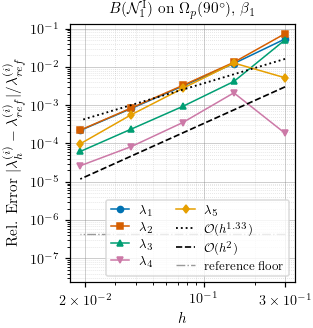

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


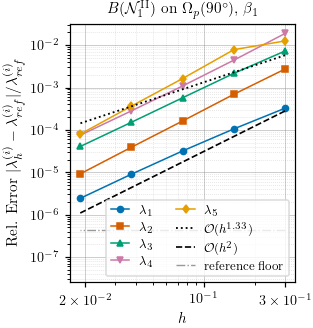

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


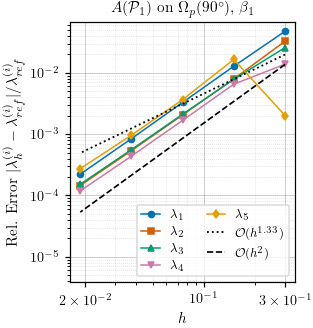

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


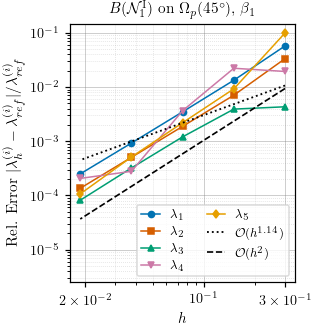

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


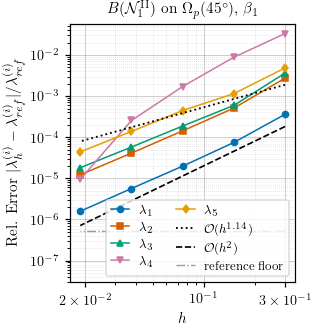

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


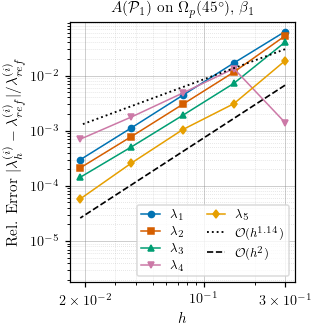

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


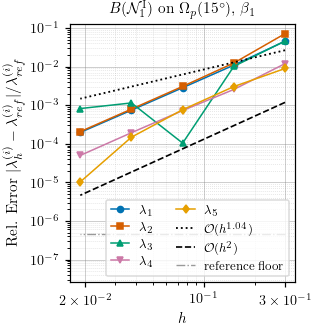

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


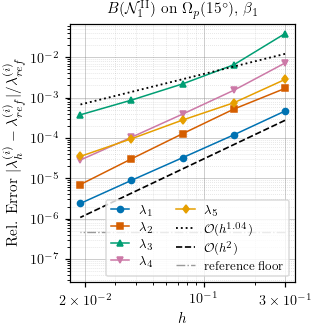

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


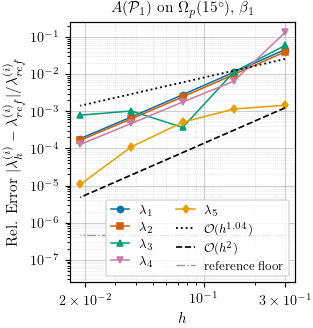

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


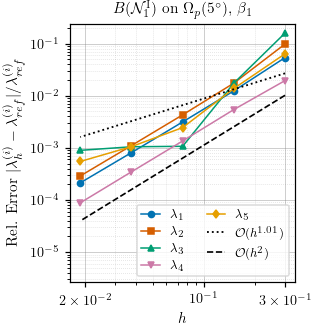

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


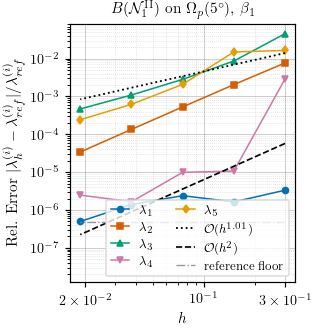

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


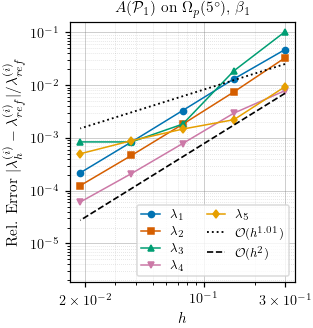

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


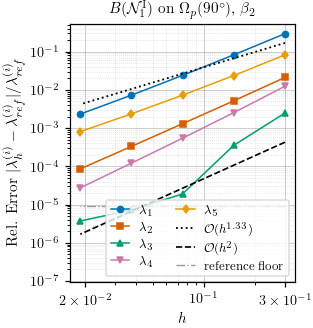

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


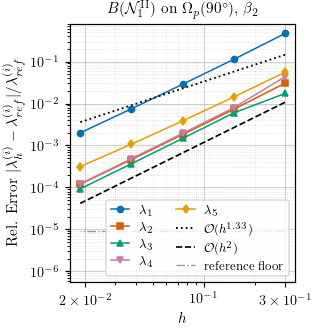

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


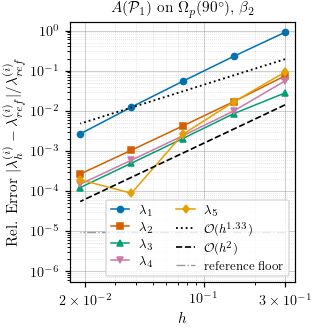

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


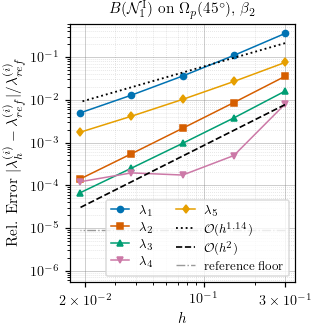

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


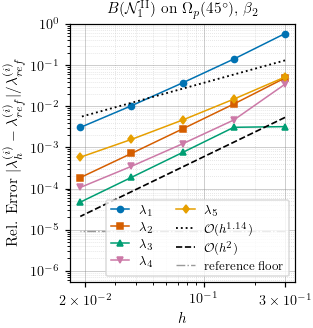

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


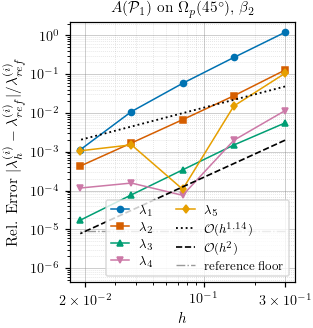

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


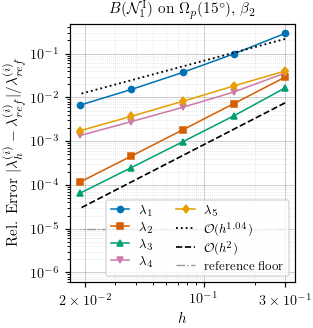

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


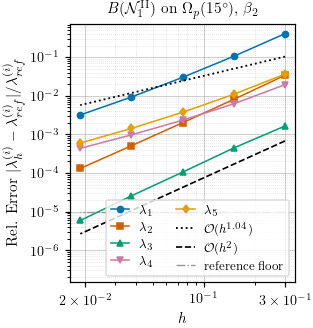

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


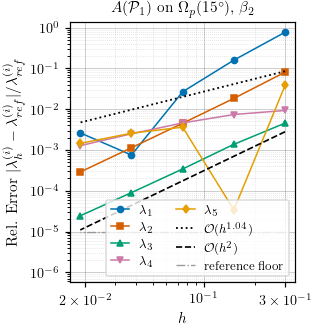

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


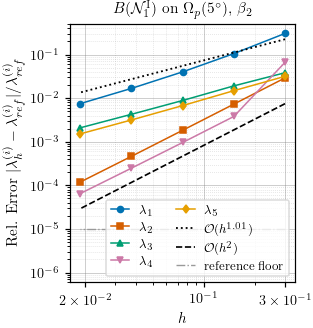

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


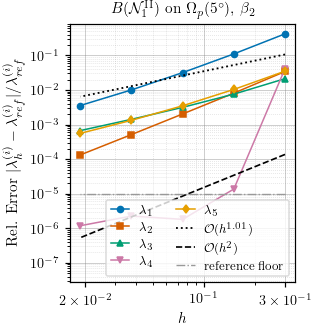

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


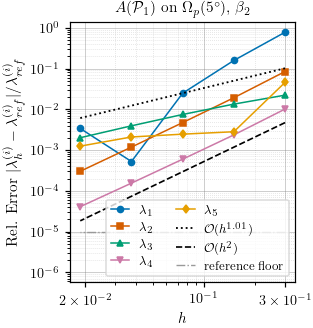

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


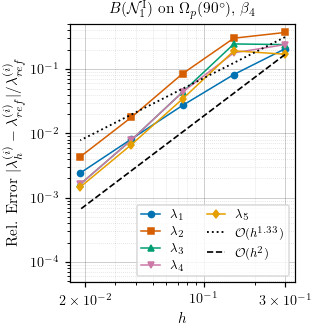

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


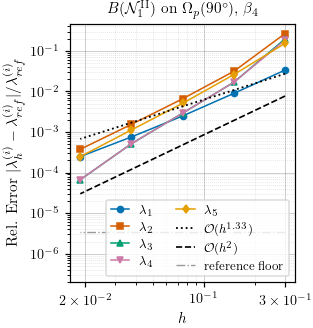

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


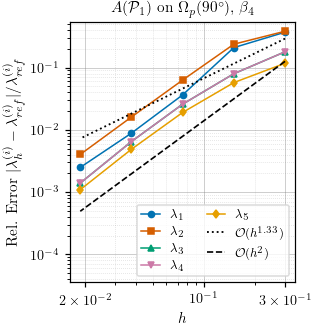

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


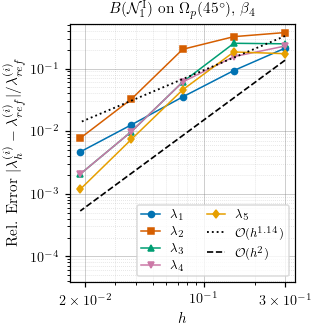

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


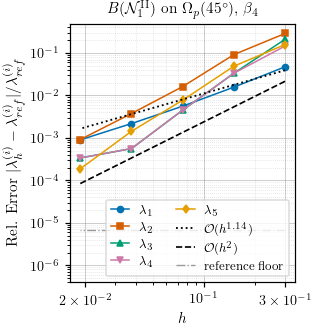

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


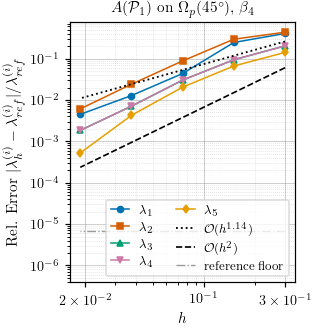

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


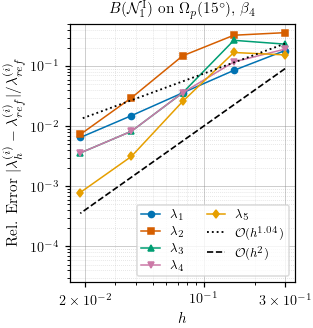

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


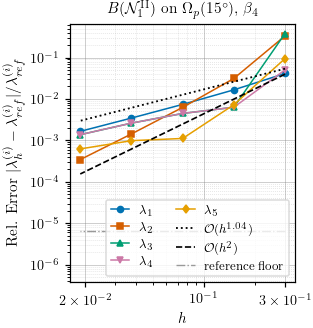

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


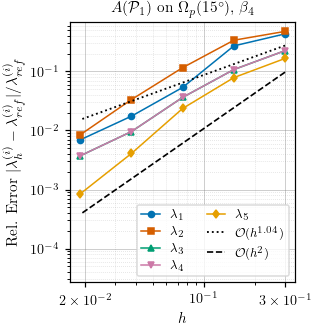

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


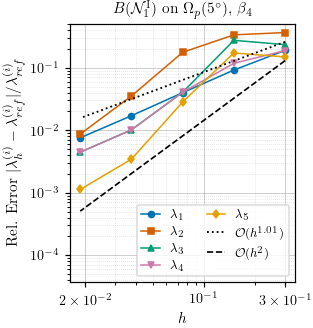

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


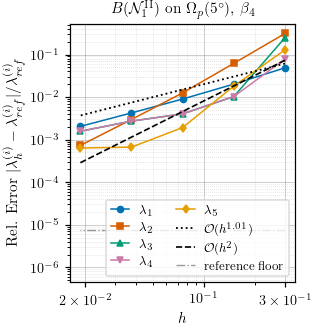

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


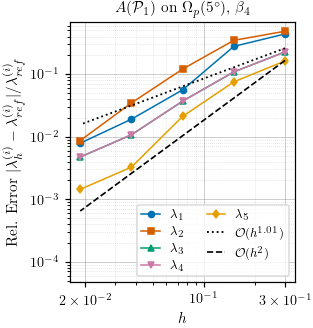

In [11]:
H_TICKS = [0.02, 0.1, 0.3]
H_TICKLABELS = [r"$2\times10^{-2}$", r"$10^{-1}$", r"$3\times10^{-1}$"]


def slowest_fastest(df):
    """The tracked modes with the largest and smallest error on the finest mesh.

    Which mode the corner limits is not known in advance once advection has
    reordered the spectrum, so the two reference slopes are anchored to whichever
    modes the panel actually has, at the level where the asymptotics have set in.
    """
    finest = df[EIG_COLS].to_numpy()[-1]
    return EIG_COLS[int(np.argmax(finest))], EIG_COLS[int(np.argmin(finest))]


for k in ADVECTED:
    for d in DELTAS:
        rate = SECTOR[d]["h_rate"]
        floor = CV_FLOOR[(k, d)].max()
        for f in FORMS:
            df = h_study[(f, d, k)]
            h = df["h"].to_numpy()
            slow, fast = slowest_fastest(df)
            es, ef = df[slow].to_numpy(), df[fast].to_numpy()
            conv_panel(
                h, [(rf"$\lambda_{{{j+1}}}$", df[EIG_COLS[j]].to_numpy())
                    for j in range(N_EIGS)],
                refs=[(h, 1.8 * es[-1] * (h / h[-1]) ** rate,
                       dict(ls=":", lw=1.2,
                            label=rf"$\mathcal{{O}}(h^{{{rate:.2f}}})$")),
                      (h, 0.45 * ef[-1] * (h / h[-1]) ** 2,
                       dict(ls="--", lw=1.1, label=r"$\mathcal{O}(h^{2})$")),
                      ] + floor_ref(h, df[EIG_COLS].to_numpy(), floor),
                xlabel=r"$h$", ylabel=REL_ERR,
                title=rf"{TEX1[f]} on $\Omega_p({d:g}^\circ)$, {FIELDS[k].tex}",
                xticks=H_TICKS, xticklabels=H_TICKLABELS,
                name=f"pacman_h_{k}_{TAG[f]}_d{d:g}")

$p$-study: level-1 mesh ($h = 0.15$), $p = 1,\dots,4$, `nev = 50`, same 36 configurations (`pacman_p_<wind>_<form>_d<delta>.eps`). The thesis uses `pacman_p_b1_BN2_d15.eps`; guide $\mathcal{O}(p^{-4\alpha})$ ($4\alpha = 2.09$ at $15^\circ$).


In [12]:
def sector_p_study(form, delta, field_key, level=P_LEVEL, degrees=P_DEGREES,
                   n_eigs=N_EIGS):
    r"""$p$-refinement on one fixed mesh, against the graded reference."""
    ref = REF[(field_key, delta)]["adopted"][:n_eigs]
    mesh = sector_hierarchy(delta, SECTOR_LEVELS, maxh=SECTOR_MAXH)[level]
    beta = FIELDS[field_key](mesh)
    rows = []
    for r in degrees:
        res = solve_form(form, mesh, r, beta=beta, nev=H_NEV, cond=False)
        got = assign(ref, res.values)
        rows.append(dict(r=r, dof=res.size,
                         **{EIG_COLS[j]: abs(got[j] - ref[j]) / abs(ref[j])
                            for j in range(n_eigs)}))
        del res
    return pd.DataFrame(rows).set_index("r")


t_start = time.time()
p_study = {}
for k in ADVECTED:
    for d in DELTAS:
        for f in FORMS:
            p_study[(f, d, k)] = sector_p_study(f, d, k)
        print(f"  p-study {k} {d:5.1f} done [{time.time() - t_start:.0f}s]", flush=True)
print(f"p-refinement complete in {(time.time() - t_start) / 60:.1f} min")

  p-study b1  90.0 done [10s]


  p-study b1  45.0 done [12s]


  p-study b1  15.0 done [16s]


  p-study b1   5.0 done [19s]


  p-study b2  90.0 done [24s]


...

  p-study b4  90.0 done [35s]


  p-study b4  45.0 done [37s]


  p-study b4  15.0 done [39s]


  p-study b4   5.0 done [41s]


p-refinement complete in 0.7 min


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


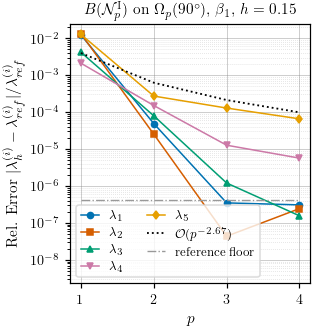

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


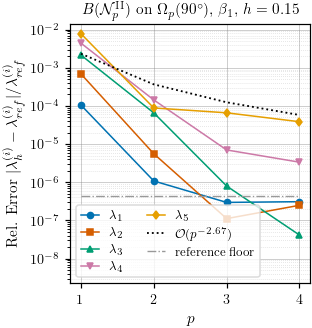

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


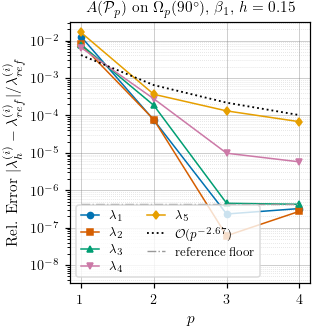

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


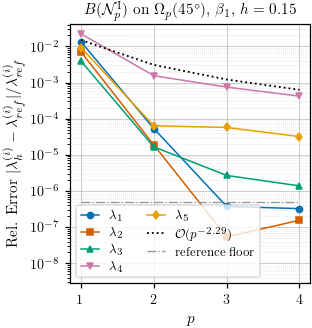

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


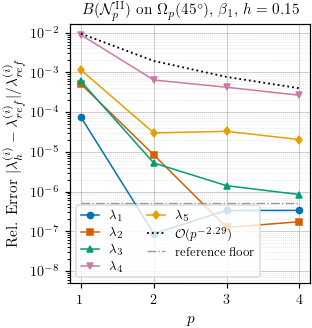

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


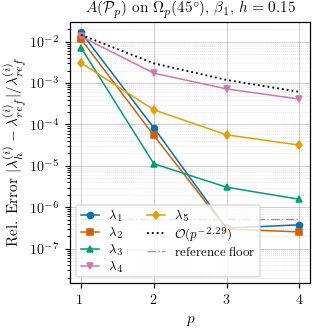

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


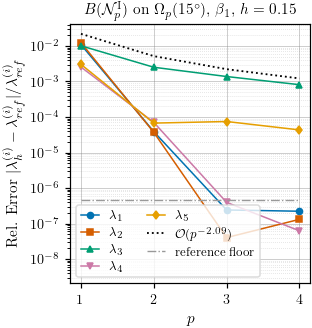

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


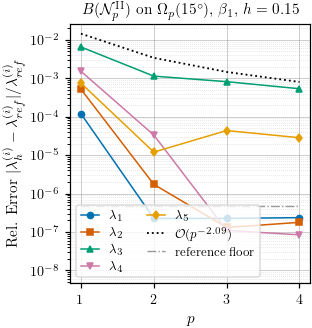

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


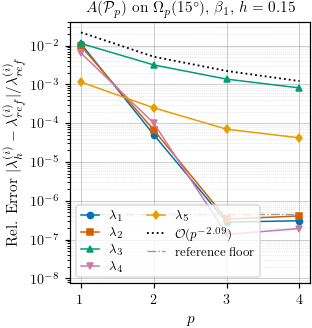

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


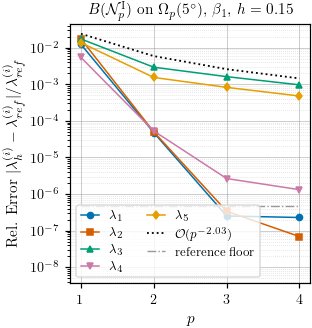

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


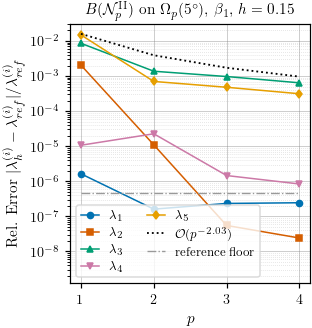

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


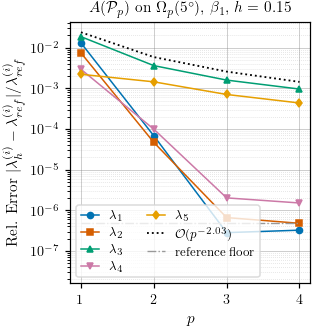

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


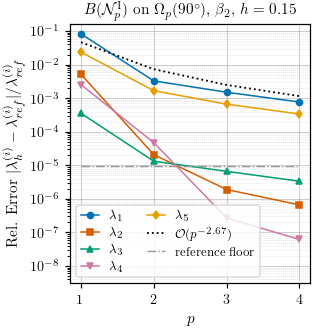

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


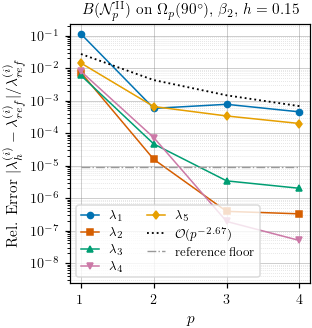

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


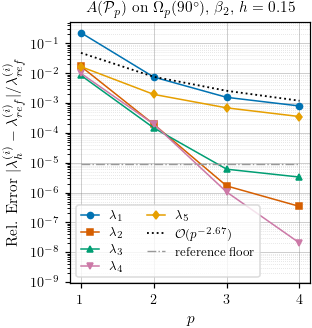

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


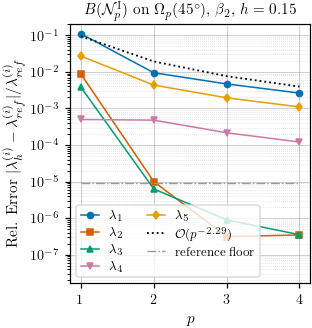

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


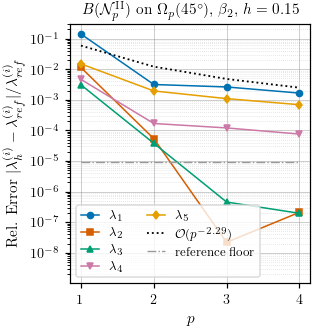

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


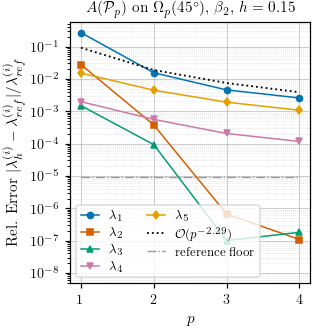

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


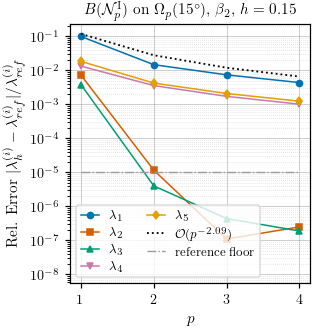

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


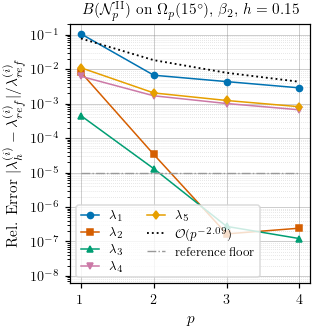

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


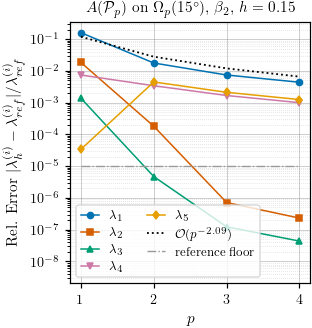

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


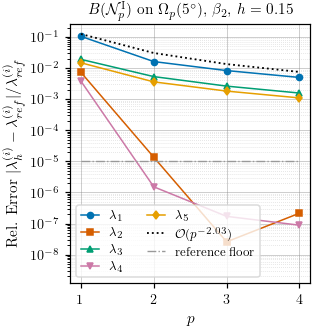

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


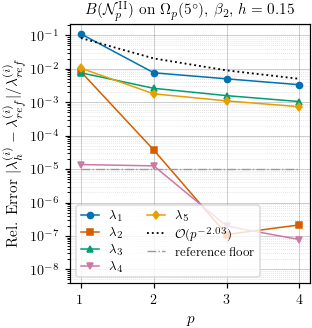

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


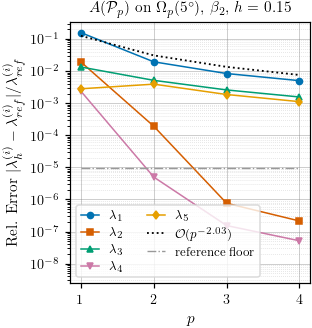

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


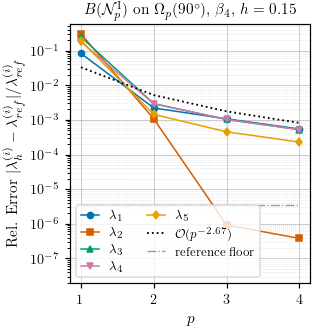

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


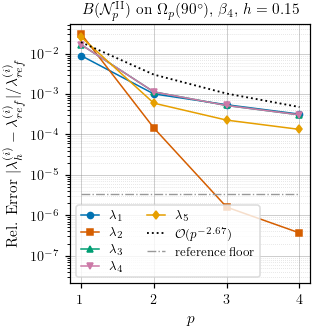

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


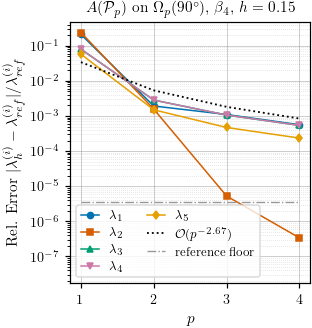

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


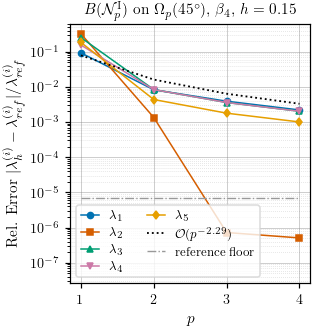

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


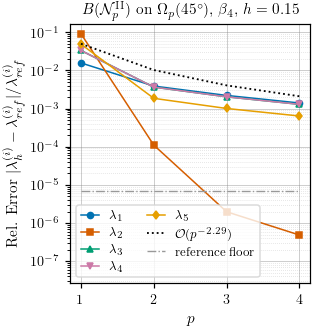

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


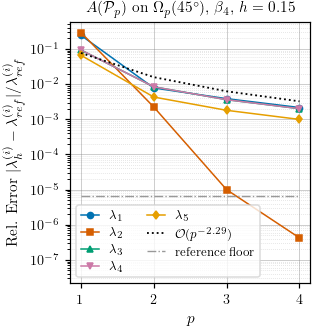

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


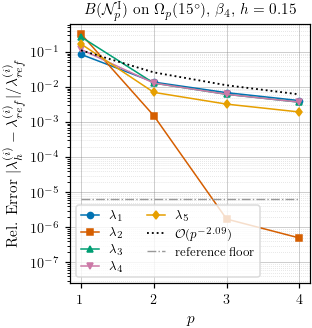

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


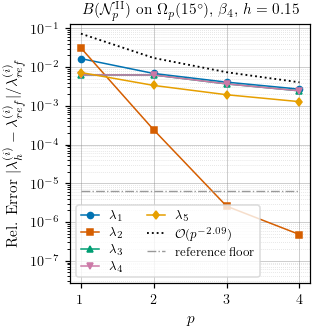

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


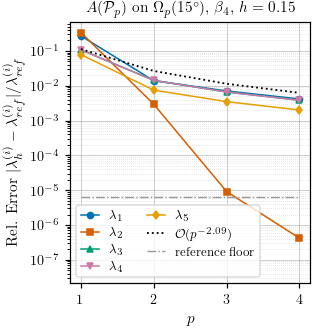

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


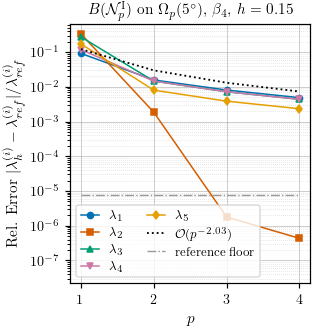

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


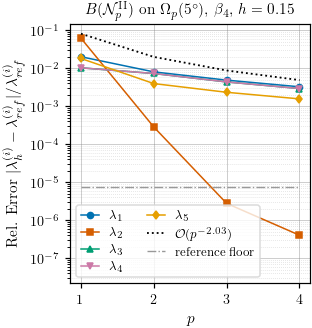

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


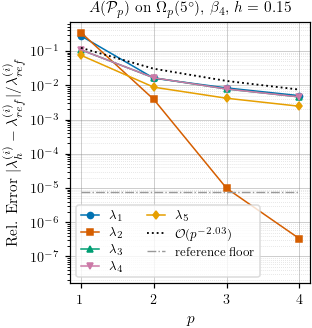

In [13]:
P_H = SECTOR_MAXH / 2 ** P_LEVEL

for k in ADVECTED:
    for d in DELTAS:
        q = SECTOR[d]["p_rate"]
        floor = CV_FLOOR[(k, d)].max()
        for f in FORMS:
            df = p_study[(f, d, k)]
            pp = np.asarray(df.index, float)
            slow, _ = slowest_fastest(df)
            es = df[slow].to_numpy()
            conv_panel(
                pp, [(rf"$\lambda_{{{j+1}}}$", df[EIG_COLS[j]].to_numpy())
                     for j in range(N_EIGS)],
                refs=[(pp, 1.5 * es[-1] * (pp / pp[-1]) ** (-q),
                       dict(ls=":", lw=1.2,
                            label=rf"$\mathcal{{O}}(p^{{-{q:.2f}}})$")),
                      ] + floor_ref(pp, df[EIG_COLS].to_numpy(), floor),
                xlabel=r"$p$", ylabel=REL_ERR,
                title=rf"{TEXP[f]} on $\Omega_p({d:g}^\circ)$, {FIELDS[k].tex}, "
                      rf"$h={P_H:g}$",
                logx=False, xticks=P_DEGREES, numticks=40,
                legend_loc="lower left",
                name=f"pacman_p_{k}_{TAG[f]}_d{d:g}")

# Appendix


## Figure A.11: Unstructured meshes for the re-entrant sector Ω_s(δ)


Quasi-uniform hierarchy at $\delta = 90^\circ$, levels 0-2 (`pacman_mesh_d90_l0.eps`, `..._l1`, `..._l2`), the level-2 mesh at $\delta = 45^\circ, 15^\circ, 5^\circ$ (`pacman_mesh_d45_l2.eps`, `pacman_mesh_d15_l2.eps`, `pacman_mesh_d5_l2.eps`), and the graded reference mesh with a corner zoom at $90^\circ$ and $5^\circ$ (`pacman_mesh_graded_*.eps`); `SECTOR_MAXH = 0.30`, rim isoparametric at degree 2. Panels (a) and (b) of the thesis figure are `pacman_mesh_d90_l0.eps` and `pacman_mesh_d15_l2.eps`; the thesis PDF used two files from an older mesh generator outside this folder (`pacman_mesh_level_0.eps`, 192 cells, and `pacman_closing_15deg_level_2.eps`); they are shipped in `figures/` but are not regenerated by this notebook, whose level-0 mesh has 98 cells (see Notes).


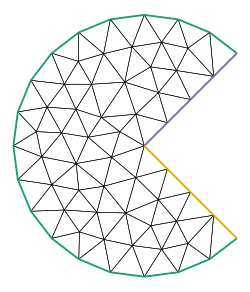

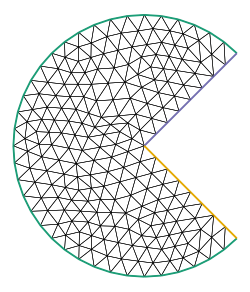

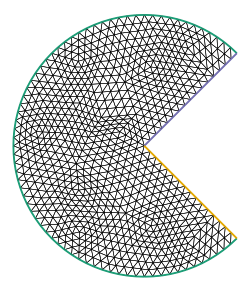

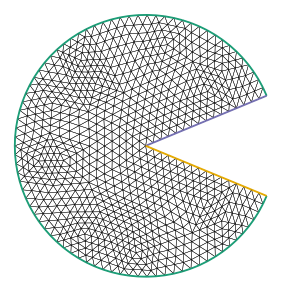

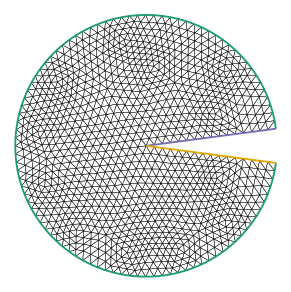

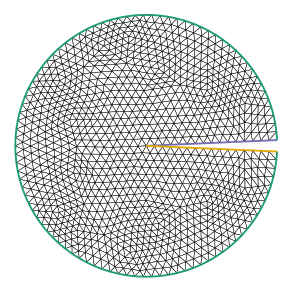

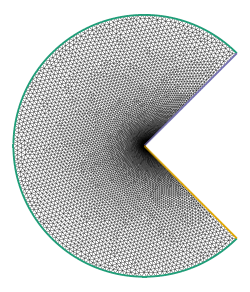

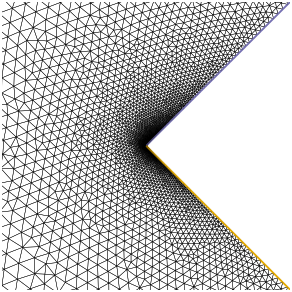

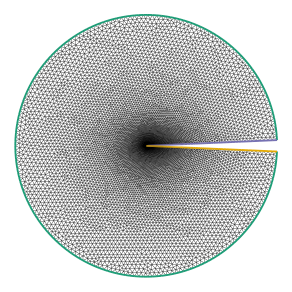

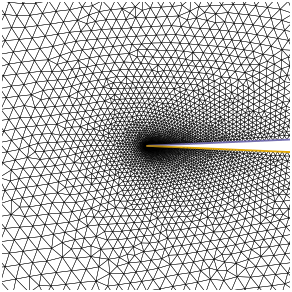

In [14]:
# The hierarchy the rates are measured on, and the mouth closing at fixed level.
for lvl in (0, 1, 2):
    mesh_panel(sector_hierarchy(90.0, SECTOR_LEVELS, maxh=SECTOR_MAXH)[lvl],
               f"pacman_mesh_d90_l{lvl}")

for d in (45.0, 15.0, 5.0):
    mesh_panel(sector_hierarchy(d, SECTOR_LEVELS, maxh=SECTOR_MAXH)[2],
               f"pacman_mesh_d{d:g}_l2", lw=0.25)

# The reference mesh, and the same mesh zoomed on the corner: the grading is
# invisible at domain scale and is the whole point of the mesh.
for d in (90.0, 5.0):
    mesh_panel(base_mesh(d), f"pacman_mesh_graded_d{d:g}", lw=0.12)
    fig, ax = plt.subplots(figsize=FIG_SQ)
    triplot(base_mesh(d), axes=ax, interior_kw={"linewidths": 0.25})
    ax.set_xlim(-0.06, 0.06); ax.set_ylim(-0.06, 0.06)
    ax.set_aspect("equal"); ax.axis("off")
    save_fig(fig, f"pacman_mesh_graded_zoom_d{d:g}")
    plt.show()

## Table A.13: Reference spectrum for β1 on Ω_s(δ)


Tabulates `REF` computed in Setup: for each wind and angle, all 100 eigenvalues from $B(\mathcal{N}^{\mathrm{I}}_2)$, $B(\mathcal{N}^{\mathrm{II}}_2)$, $A(\mathcal{P}_2)$ on the graded reference mesh (22,505 / 25,952 / 26,072 / 27,286 cells at $90^\circ$ / $45^\circ$ / $15^\circ$ / $5^\circ$), $R_m = 10$, $\tau = 1$, with the adopted mean, spread, matching digits, $|\mathrm{Im}\,\lambda|$, and the MUMPS $\kappa(A - \tau M)$ and `INFOG(1)` rows. The twelve tables are printed in the order $\beta_1$, $\beta_2$, $\beta_4$, each at $90^\circ, 45^\circ, 15^\circ, 5^\circ$; the thesis quotes the first 5 rows. Table A.13 is the first four tables.


In [15]:
def reference_frame(field_key, delta, modes=None):
    """One reference table: the three formulations, their mean, and the spread."""
    cv = REF[(field_key, delta)]
    idx = range(cv["n"]) if modes is None else range(min(modes, cv["n"]))
    rows = {}
    for j in idx:
        rows[rf"$\lambda_{{{j+1}}}$"] = {
            **{f: format_eig(cv["values"][i, j]) for i, f in enumerate(FORMS)},
            "adopted": format_eig(cv["adopted"][j]),
            "spread": cv["spread"][j],
            "digits": cv["digits"][j],
            r"$|\mathrm{Im}\,\lambda|$": abs(cv["adopted"][j].imag)}
    rows[r"MUMPS $\kappa(A-\tau M)$"] = {
        **{f: f"{cv['kappas'][f]:.3e}" for f in FORMS},
        "adopted": "--", "spread": np.nan, "digits": np.nan,
        r"$|\mathrm{Im}\,\lambda|$": np.nan}
    rows[r"INFOG(1)"] = {
        **{f: f"{cv['infogs'][f]:d}" for f in FORMS},
        "adopted": "--", "spread": np.nan, "digits": np.nan,
        r"$|\mathrm{Im}\,\lambda|$": np.nan}
    return pd.DataFrame(rows).T.fillna("--")


REF_RULES = [("spread", "{:.2e}"), ("digits", "{:.0f}"),
             (r"$|\mathrm{Im}\,\lambda|$", "{:.1e}")]

for k in ADVECTED:
    for d in DELTAS:
        cv = REF[(k, d)]
        display(show(reference_frame(k, d), default="{:.9f}", rules=REF_RULES,
                     caption=rf"Reference spectrum for {FIELDS[k].tex} on "
                             rf"$\Omega_p({d:g}^\circ)$ at $R_m={RM:g}$, "
                             rf"$\tau={TAU:g}$: all {cv['n']} eigenvalues, "
                             rf"degree {BASE_R} on the graded reference mesh "
                             rf"({cv['cells']} cells; DoF "
                             + ", ".join(f"{f} {cv['dof'][f]}" for f in FORMS)
                             + r"). The adopted value is the mean of the three; "
                               r"`spread` is the diameter of the three and `digits` "
                               r"the significant figures they agree on. The last "
                               r"two rows are MUMPS' own condition estimate "
                               r"RINFOG(10) of $A-\tau M$ and its INFOG(1), which "
                               r"is $0$ exactly when the factorisation succeeded."))

**Reference spectrum for $\beta_1$ on $\Omega_p(90^\circ)$ at $R_m=10$, $\tau=1$: all 100 eigenvalues, degree 2 on the graded reference mesh (22505 cells; DoF B(N1) 159002, B(N2) 272260, A(P) 45745). The adopted value is the mean of the three; `spread` is the diameter of the three and `digits` the significant figures they agree on. The last two rows are MUMPS' own condition estimate RINFOG(10) of $A-\tau M$ and its INFOG(1), which is $0$ exactly when the factorisation succeeded.**

,B(N1),B(N2),A(P),adopted,spread,digits,"$|\mathrm{Im}\,\lambda|$"
$\lambda_{1}$,1.474070634,1.474070944,1.474071264,1.474070947,6.30e-07,6,0.0e+00
$\lambda_{2}$,2.819317360,2.819317764,2.819318130,2.819317751,7.70e-07,6,0.0e+00
$\lambda_{3}$,4.023963982,4.023964190,4.023964663,4.023964278,6.81e-07,6,0.0e+00
$\lambda_{4}$,5.049408396,5.049408118,5.049408569,5.049408361,4.50e-07,7,0.0e+00
$\lambda_{5}$,5.640571781,5.640571879,5.640572436,5.640572032,6.55e-07,6,0.0e+00
$\lambda_{6}$,6.149280120,6.149279486,6.149280553,6.149280053,1.07e-06,6,0.0e+00
$\lambda_{7}$,6.526124107,6.526124778,6.526127762,6.526125549,3.66e-06,6,0.0e+00
$\lambda_{8}$,6.974006184,6.974004696,6.974005816,6.974005565,1.49e-06,6,0.0e+00
$\lambda_{9}$,7.627640809,7.627639657,7.627640716,7.627640394,1.15e-06,6,0.0e+00
$\lambda_{10}$,7.863942951,7.863940064,7.863939227,7.863940747,3.72e-06,6,0.0e+00


**Reference spectrum for $\beta_1$ on $\Omega_p(45^\circ)$ at $R_m=10$, $\tau=1$: all 100 eigenvalues, degree 2 on the graded reference mesh (25952 cells; DoF B(N1) 183181, B(N2) 313699, A(P) 52664). The adopted value is the mean of the three; `spread` is the diameter of the three and `digits` the significant figures they agree on. The last two rows are MUMPS' own condition estimate RINFOG(10) of $A-\tau M$ and its INFOG(1), which is $0$ exactly when the factorisation succeeded.**

,B(N1),B(N2),A(P),adopted,spread,digits,"$|\mathrm{Im}\,\lambda|$"
$\lambda_{1}$,1.474043690,1.474043984,1.474044442,1.474044039,7.52e-07,6,0.0e+00
$\lambda_{2}$,2.818480435,2.818480511,2.818481641,2.818480862,1.21e-06,6,0.0e+00
$\lambda_{3}$,4.014480170,4.014479984,4.014481760,4.014480638,1.78e-06,6,0.0e+00
$\lambda_{4}$,4.826247332,4.826247518,4.826247645,4.826247498,3.12e-07,7,0.0e+00
$\lambda_{5}$,5.036810332,5.036810160,5.036811697,5.036810730,1.54e-06,6,0.0e+00
$\lambda_{6}$,5.801653626,5.801653702,5.801655275,5.801654201,1.65e-06,6,0.0e+00
$\lambda_{7}$,6.141076768,6.141076796,6.141078926,6.141077497,2.16e-06,6,0.0e+00
$\lambda_{8}$,6.618168442,6.618168342,6.618169443,6.618168742,1.10e-06,6,0.0e+00
$\lambda_{9}$,6.891154086,6.891153070,6.891154485,6.891153880,1.42e-06,6,0.0e+00
$\lambda_{10}$,7.284314158,7.284313415,7.284314017,7.284313863,7.43e-07,6,0.0e+00


**Reference spectrum for $\beta_1$ on $\Omega_p(15^\circ)$ at $R_m=10$, $\tau=1$: all 100 eigenvalues, degree 2 on the graded reference mesh (26072 cells; DoF B(N1) 184045, B(N2) 315175, A(P) 52916). The adopted value is the mean of the three; `spread` is the diameter of the three and `digits` the significant figures they agree on. The last two rows are MUMPS' own condition estimate RINFOG(10) of $A-\tau M$ and its INFOG(1), which is $0$ exactly when the factorisation succeeded.**

...

,B(N1),B(N2),A(P),adopted,spread,digits,"$|\mathrm{Im}\,\lambda|$"
$\lambda_{1}$,0.895713097,0.895712548,0.895712012,0.895712552,1.09e-06,5,0.0e+00
$\lambda_{2}$,1.468192297,1.468196985,1.468202178,1.468197153,9.88e-06,5,0.0e+00
$\lambda_{3}$,1.699781098+0.576539706i,1.699781292+0.576537086i,1.699781906+0.576534053i,1.699781432+0.576536948i,5.71e-06,5,5.8e-01
$\lambda_{4}$,1.699781098-0.576539706i,1.699781292-0.576537086i,1.699781906-0.576534053i,1.699781432-0.576536948i,5.71e-06,5,5.8e-01
$\lambda_{5}$,2.462590006+1.016484581i,2.462589586+1.016482101i,2.462590084+1.016478619i,2.462589892+1.016481767i,5.96e-06,5,1.0e+00
$\lambda_{6}$,2.462590006-1.016484581i,2.462589586-1.016482101i,2.462590084-1.016478619i,2.462589892-1.016481767i,5.96e-06,5,1.0e+00
$\lambda_{7}$,3.350354505+1.343266738i,3.350351330+1.343264760i,3.350348926+1.343259000i,3.350351587+1.343263499i,9.54e-06,5,1.3e+00
$\lambda_{8}$,3.350354505-1.343266738i,3.350351330-1.343264760i,3.350348926-1.343259000i,3.350351587-1.343263499i,9.54e-06,5,1.3e+00
$\lambda_{9}$,4.417276677+1.576977215i,4.417265810+1.576980285i,4.417250906+1.576962163i,4.417264464+1.576973221i,2.98e-05,5,1.6e+00
$\lambda_{10}$,4.417276677-1.576977215i,4.417265810-1.576980285i,4.417250906-1.576962163i,4.417264464-1.576973221i,2.98e-05,5,1.6e+00


**Reference spectrum for $\beta_4$ on $\Omega_p(15^\circ)$ at $R_m=10$, $\tau=1$: all 100 eigenvalues, degree 2 on the graded reference mesh (26072 cells; DoF B(N1) 184045, B(N2) 315175, A(P) 52916). The adopted value is the mean of the three; `spread` is the diameter of the three and `digits` the significant figures they agree on. The last two rows are MUMPS' own condition estimate RINFOG(10) of $A-\tau M$ and its INFOG(1), which is $0$ exactly when the factorisation succeeded.**

,B(N1),B(N2),A(P),adopted,spread,digits,"$|\mathrm{Im}\,\lambda|$"
$\lambda_{1}$,0.833507281,0.833507010,0.833506909,0.833507067,3.72e-07,6,0.0e+00
$\lambda_{2}$,1.468192111,1.468197029,1.468201586,1.468196909,9.48e-06,5,0.0e+00
$\lambda_{3}$,1.576533316+0.557653393i,1.576533262+0.557651038i,1.576533630+0.557648650i,1.576533403+0.557651027i,4.75e-06,5,5.6e-01
$\lambda_{4}$,1.576533316-0.557653393i,1.576533262-0.557651038i,1.576533630-0.557648650i,1.576533403-0.557651027i,4.75e-06,5,5.6e-01
$\lambda_{5}$,2.269973520+0.993911904i,2.269973072+0.993909728i,2.269973379+0.993907075i,2.269973324+0.993909569i,4.83e-06,5,9.9e-01
$\lambda_{6}$,2.269973520-0.993911904i,2.269973072-0.993909728i,2.269973379-0.993907075i,2.269973324-0.993909569i,4.83e-06,5,9.9e-01
$\lambda_{7}$,3.069622641+1.327656016i,3.069620007+1.327654425i,3.069618280+1.327650581i,3.069620309+1.327653674i,6.97e-06,5,1.3e+00
$\lambda_{8}$,3.069622641-1.327656016i,3.069620007-1.327654425i,3.069618280-1.327650581i,3.069620309-1.327653674i,6.97e-06,5,1.3e+00
$\lambda_{9}$,4.025566214+1.585318172i,4.025558598+1.585320491i,4.025549947+1.585311851i,4.025558253+1.585316838i,1.75e-05,5,1.6e+00
$\lambda_{10}$,4.025566214-1.585318172i,4.025558598-1.585320491i,4.025549947-1.585311851i,4.025558253-1.585316838i,1.75e-05,5,1.6e+00


**Reference spectrum for $\beta_4$ on $\Omega_p(5^\circ)$ at $R_m=10$, $\tau=1$: all 100 eigenvalues, degree 2 on the graded reference mesh (27286 cells; DoF B(N1) 192559, B(N2) 329767, A(P) 55352). The adopted value is the mean of the three; `spread` is the diameter of the three and `digits` the significant figures they agree on. The last two rows are MUMPS' own condition estimate RINFOG(10) of $A-\tau M$ and its INFOG(1), which is $0$ exactly when the factorisation succeeded.**

,B(N1),B(N2),A(P),adopted,spread,digits,"$|\mathrm{Im}\,\lambda|$"
$\lambda_{1}$,0.814761474,0.814761224,0.814761088,0.814761262,3.86e-07,6,0.0e+00
$\lambda_{2}$,1.468191613,1.468196892,1.468202622,1.468197042,1.10e-05,5,0.0e+00
$\lambda_{3}$,1.539577479+0.551490779i,1.539577396+0.551488433i,1.539577535+0.551485676i,1.539577470+0.551488296i,5.10e-06,5,5.5e-01
$\lambda_{4}$,1.539577479-0.551490779i,1.539577396-0.551488433i,1.539577535-0.551485676i,1.539577470-0.551488296i,5.10e-06,5,5.5e-01
$\lambda_{5}$,2.212596317+0.986071315i,2.212596012+0.986069004i,2.212595856+0.986066081i,2.212596062+0.986068800i,5.25e-06,5,9.9e-01
$\lambda_{6}$,2.212596317-0.986071315i,2.212596012-0.986069004i,2.212595856-0.986066081i,2.212596062-0.986068800i,5.25e-06,5,9.9e-01
$\lambda_{7}$,2.986363211+1.321614170i,2.986360752+1.321612085i,2.986357820+1.321609029i,2.986360595+1.321611761i,7.45e-06,5,1.3e+00
$\lambda_{8}$,2.986363211-1.321614170i,2.986360752-1.321612085i,2.986357820-1.321609029i,2.986360595-1.321611761i,7.45e-06,5,1.3e+00
$\lambda_{9}$,3.909397874+1.585790865i,3.909390272+1.585791224i,3.909379531+1.585790815i,3.909389225+1.585790968i,1.83e-05,5,1.6e+00
$\lambda_{10}$,3.909397874-1.585790865i,3.909390272-1.585791224i,3.909379531-1.585790815i,3.909389225-1.585790968i,1.83e-05,5,1.6e+00


## Table A.14: Reference spectrum for β2 on Ω_s(δ)


Produced by the cell under Table A.13 above: tables 5-8 of its output ($\beta_2$ at $90^\circ, 45^\circ, 15^\circ, 5^\circ$).


## Table A.15: Reference spectrum for β4 on Ω_s(δ)


Produced by the cell under Table A.13 above: tables 9-12 of its output ($\beta_4$ at $90^\circ, 45^\circ, 15^\circ, 5^\circ$; complex pairs shown as `re+im i`).


## Notes

(a) Parameter re-runs: none. Every code cell is a verbatim copy of `domain_regularity_pacman.ipynb` with its stored outputs.

(b) Caveats (reported, not fixed):
- Figure A.11: the thesis `\includegraphics` files `pacman_mesh_level_0.eps` (192 cells at $\delta = 90^\circ$) and `pacman_closing_15deg_level_2.eps` come from an older mesh generator that is not in this folder; no cell here writes them. The cell above draws the corresponding meshes of this notebook's hierarchy as `pacman_mesh_d90_l0.eps` and `pacman_mesh_d15_l2.eps`, with the same $h_{\max} = 0.30$ but a different triangulation (98 cells at level 0, see the hierarchy table in Setup).
- Figure 4.15: the caption says "100 eigenvalues"; the $h$- and $p$-study cells request `H_NEV = 50` eigenpairs (100 is the count of the reference solve). The panel titles label the domain $\Omega_p$ where the thesis writes $\Omega_s$.
- Tables A.13-A.15: the thesis prints the first 5 eigenvalues, spread, digits and $\kappa$; the cell also prints the adopted mean, $|\mathrm{Im}\,\lambda|$, `INFOG(1)` and rows 6-100. All printed numbers agree with the thesis tables.
- The Setup cell at $\beta = 0$ (validation of the graded mesh against the exact sector spectrum) is not a thesis item; it is kept because the thesis text justifies the graded reference by it.

(c) Dropped cells from the source notebook: 0, 4, 7, 11, 13, 16, 19, 22, 26, 32 (markdown essays); 23-25 (eigenfunction-gap study, Section 7, not a thesis item); 27-31 (pseudospectra grids and bulge summary, Section 8, not a thesis item).
